In [10]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, precision_score, recall_score, f1_score, ConfusionMatrixDisplay)

# Convulation Neural Network CNN

In [25]:
#data loader
digits = load_digits()
X = digits.images
y = digits.target
X = X / 16.0 # Normalize pixel values
X = X.reshape(-1, 1, 8, 8)
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [11]:
#CNN model architecture
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(8*4*4,32)
        self.fc2 = nn.Linear(32,10)
        self.relu = nn.ReLU()
    def forward(self,x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = x.view(x.size(0),-1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x
model = DigitCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

summary(model, input_size=(1, 1, 8, 8))

Layer (type:depth-idx)                   Output Shape              Param #
DigitCNN                                 [1, 10]                   --
├─Conv2d: 1-1                            [1, 8, 8, 8]              80
├─ReLU: 1-2                              [1, 8, 8, 8]              --
├─MaxPool2d: 1-3                         [1, 8, 4, 4]              --
├─Linear: 1-4                            [1, 32]                   4,128
├─ReLU: 1-5                              [1, 32]                   --
├─Linear: 1-6                            [1, 10]                   330
Total params: 4,538
Trainable params: 4,538
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.02
Estimated Total Size (MB): 0.02

In [27]:
#Model Training
epochs = 50
patience = 5 
best_loss = float("inf")
counter = 0
best_weights = copy.deepcopy(model.state_dict())
train_losses = []
val_losses = []
train_accs = []
val_accs = []
for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    running_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_loss = running_loss / len(test_loader)
    val_acc = 100 * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss={train_loss:.4f} | "
        f"Train Acc={train_acc:.2f}% | "
        f"Val Loss={val_loss:.4f} | "
        f"Val Acc={val_acc:.2f}%"
    )

    if val_loss < best_loss: #early stopping
        best_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict())
        counter = 0
        print("Validation loss improving.")
    else:
        counter += 1
        print(f"No improvement ({counter}/{patience})")
    if counter >= patience:
        print("\nEarly stopping activated.")
        break
model.load_state_dict(best_weights) # Restore best model
print("Best model restored.")

Epoch 1/50 | Train Loss=2.2669 | Train Acc=17.19% | Val Loss=2.2193 | Val Acc=47.50%
Validation loss improving.
Epoch 2/50 | Train Loss=2.1436 | Train Acc=46.49% | Val Loss=2.0337 | Val Acc=50.83%
Validation loss improving.
Epoch 3/50 | Train Loss=1.8603 | Train Acc=59.64% | Val Loss=1.6233 | Val Acc=73.33%
Validation loss improving.
Epoch 4/50 | Train Loss=1.3995 | Train Acc=72.58% | Val Loss=1.1435 | Val Acc=81.94%
Validation loss improving.
Epoch 5/50 | Train Loss=0.9784 | Train Acc=80.51% | Val Loss=0.8023 | Val Acc=86.39%
Validation loss improving.
Epoch 6/50 | Train Loss=0.7225 | Train Acc=84.27% | Val Loss=0.6061 | Val Acc=89.44%
Validation loss improving.
Epoch 7/50 | Train Loss=0.5673 | Train Acc=86.99% | Val Loss=0.4914 | Val Acc=91.39%
Validation loss improving.
Epoch 8/50 | Train Loss=0.4639 | Train Acc=89.28% | Val Loss=0.4061 | Val Acc=91.67%
Validation loss improving.
Epoch 9/50 | Train Loss=0.3930 | Train Acc=89.84% | Val Loss=0.3562 | Val Acc=92.50%
Validation loss imp

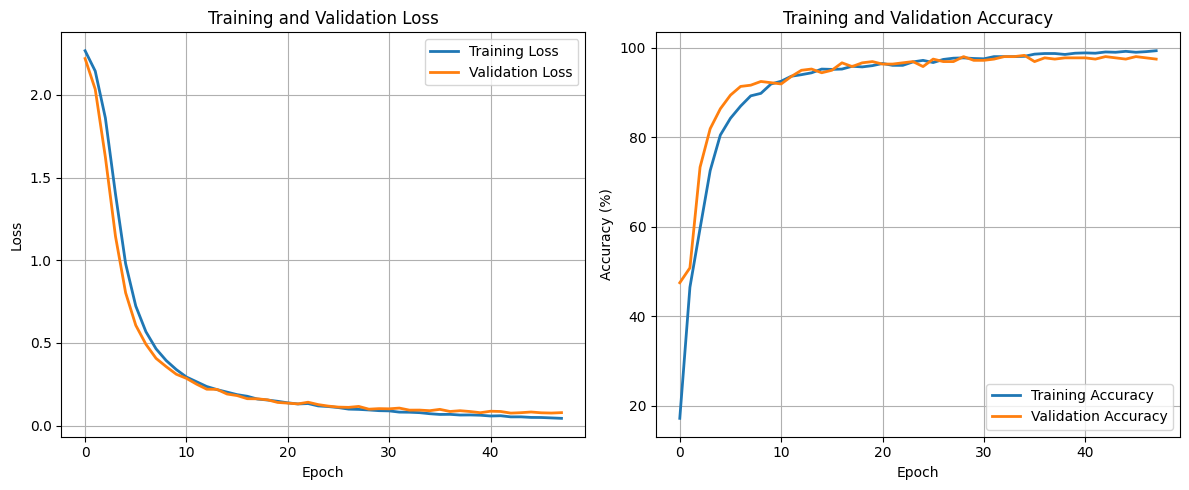

In [34]:
# Training and Validation Performance Curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, linewidth=2, label='Training Loss')
plt.plot(val_losses,  linewidth=2, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_accs, linewidth=2, label='Training Accuracy')
plt.plot(val_accs, linewidth=2, label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs,1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())

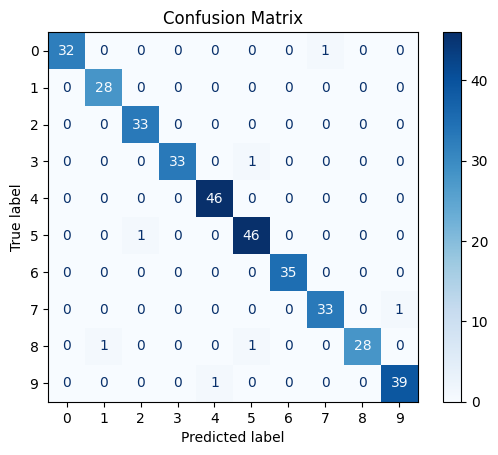

In [30]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [31]:
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")
print("Precision :", round(precision,4))
print("Recall    :", round(recall,4))
print("F1-score  :", round(f1,4))
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)]))

Precision : 0.9809
Recall    : 0.9806
F1-score  : 0.9805
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.97      1.00      0.98        28
           2       0.97      1.00      0.99        33
           3       1.00      0.97      0.99        34
           4       0.98      1.00      0.99        46
           5       0.96      0.98      0.97        47
           6       1.00      1.00      1.00        35
           7       0.97      0.97      0.97        34
           8       1.00      0.93      0.97        30
           9       0.97      0.97      0.97        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



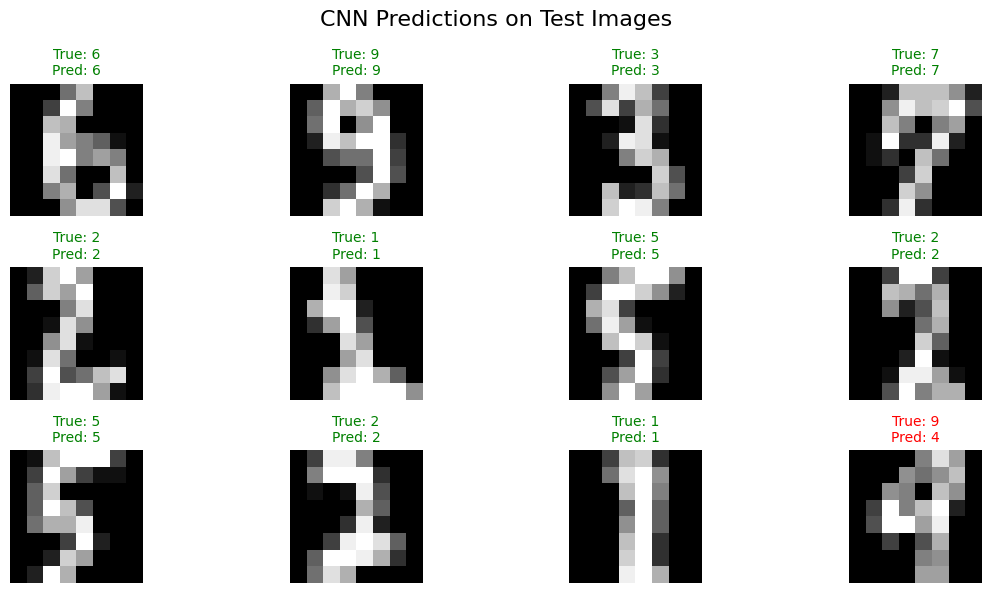

In [35]:
model.eval()
num_images = 12
plt.figure(figsize=(12,6))
count = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(images.size(0)):
            plt.subplot(3, 4, count + 1)
            plt.imshow(images[i].squeeze(), cmap='gray')
            if predicted[i] == labels[i]:
                color = "green"
            else:
                color = "red"
            plt.title(f"True: {labels[i].item()}\nPred: {predicted[i].item()}",fontsize=10,color=color)
            plt.axis("off")
            count += 1
            if count == num_images:
                break
        if count == num_images:
            break

plt.suptitle("CNN Predictions on Test Images", fontsize=16)
plt.tight_layout()
plt.show()

# Recurrent Neural Network RNN

## Hopefield Network

In [1]:
from sklearn.datasets import fetch_openml

In [3]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data
y = mnist.target.astype(int)
print("Images :", X.shape)
print("Labels :", y.shape)

Images : (70000, 784)
Labels : (70000,)


In [4]:
patterns = []
labels = []
for digit in range(10):
    idx = np.where(y == digit)[0][0]
    img = X[idx].reshape(28,28)
    bipolar = np.where(img > 127, 1, -1)
    patterns.append(bipolar.flatten())
    labels.append(digit)
patterns = np.array(patterns)
print(patterns.shape)

(10, 784)


In [14]:
class HopfieldNetwork:
    def __init__(self, neurons):
        self.n = neurons
        self.W = np.zeros((neurons, neurons))
    def train(self, patterns):
        self.W = np.zeros((self.n, self.n))
        for p in patterns:
            self.W += np.outer(p, p)
        np.fill_diagonal(self.W, 0)
        self.W /= len(patterns)
    def predict(self, x, iterations=8):
        state = x.copy()
        for _ in range(iterations):
            for i in range(self.n):
                h = np.dot(self.W[i], state)
                if h >= 0:
                    state[i] = 1
                else:
                    state[i] = -1
        return state

In [16]:
network = HopfieldNetwork(784)
print(f"Number of neurons: {network.n}")
print(f"Weight matrix: {network.W.shape}")
print(f"Total weights: {network.W.size:,}")
network.train(patterns)
print("\nTraining Complete")

Number of neurons: 784
Weight matrix: (784, 784)
Total weights: 614,656

Training Complete


In [7]:
#create a noisy digit
digit = 3
original = patterns[digit].copy()
noisy = original.copy()
noise = np.random.choice(784, int(0.20*784),replace=False) # Flip 20% pixels
noisy[noise] *= -1

In [8]:
recovered = network.predict(noisy)

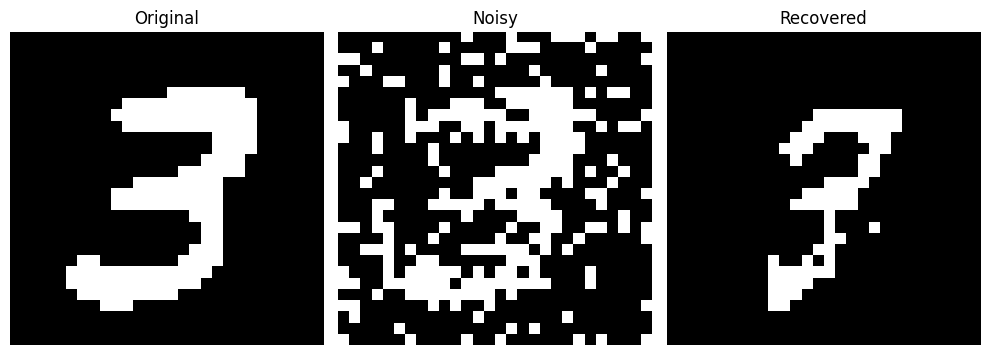

In [9]:
plt.figure(figsize=(10,4))
titles = ["Original", "Noisy", "Recovered"]
images = [original, noisy, recovered]
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(images[i].reshape(28,28), cmap="gray")
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()